In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [9]:
movies = pd.read_csv("../../datasets/raw/movielens/movies.csv")
ratings = pd.read_csv("../../datasets/raw/movielens/ratings.csv")
links = pd.read_csv("../../datasets/raw/movielens/links.csv")
tags = pd.read_csv("../../datasets/raw/movielens/tags.csv")


In [10]:
print("Movies Shape :", movies.shape)
print("Ratings Shape:", ratings.shape)
print("Links Shape  :", links.shape)
print("Tags Shape   :", tags.shape)

Movies Shape : (9742, 3)
Ratings Shape: (100836, 4)
Links Shape  : (9742, 3)
Tags Shape   : (3683, 4)


In [11]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [12]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [13]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 626.1 KB


In [14]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [15]:
print("Movies Columns")
print(movies.columns)

print("\nRatings Columns")
print(ratings.columns)

Movies Columns
Index(['movieId', 'title', 'genres'], dtype='str')

Ratings Columns
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')


In [16]:
print("Movies Missing Values")
print(movies.isnull().sum())

print("\nRatings Missing Values")
print(ratings.isnull().sum())

Movies Missing Values
movieId    0
title      0
genres     0
dtype: int64

Ratings Missing Values
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [17]:
print("Movies Duplicates:", movies.duplicated().sum())
print("Ratings Duplicates:", ratings.duplicated().sum())

Movies Duplicates: 0
Ratings Duplicates: 0


In [18]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [19]:
print("Unique Movies:", movies["movieId"].nunique())

Unique Movies: 9742


In [20]:
print("Unique Users:", ratings["userId"].nunique())

Unique Users: 610


In [21]:
print("Total Ratings:", len(ratings))

Total Ratings: 100836


In [22]:
ratings["rating"].value_counts().sort_index()

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

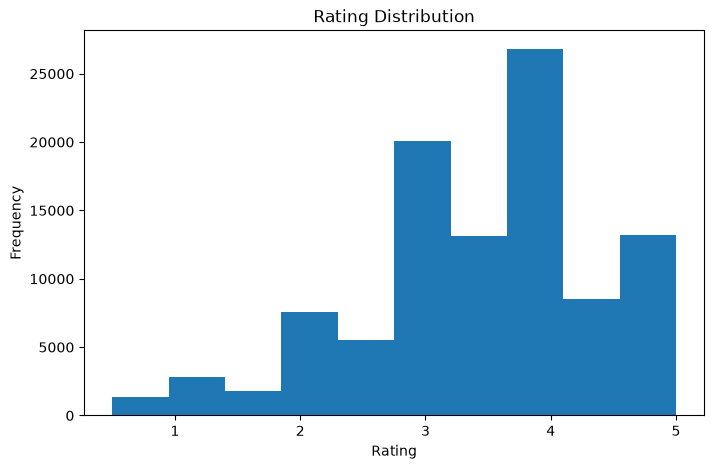

In [23]:
plt.figure(figsize=(8,5))

plt.hist(ratings["rating"], bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

In [24]:
top_movies = ratings.groupby("movieId").size()

top_movies = top_movies.sort_values(ascending=False)

top_movies.head(10)

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
dtype: int64

In [25]:
movie_ratings = ratings.merge(
    movies,
    on="movieId"
)

movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [26]:
average_rating = movie_ratings.groupby("title")["rating"].mean()

average_rating = average_rating.sort_values(ascending=False)

average_rating.head(10)

title
Karlson Returns (1970)                                                         5.0
Zeitgeist: Moving Forward (2011)                                               5.0
Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)    5.0
Dragons: Gift of the Night Fury (2011)                                         5.0
12 Angry Men (1997)                                                            5.0
Justice League: Doom (2012)                                                    5.0
Junior and Karlson (1968)                                                      5.0
Jump In! (2007)                                                                5.0
Human Condition III, The (Ningen no joken III) (1961)                          5.0
Louis Theroux: Law & Disorder (2008)                                           5.0
Name: rating, dtype: float64

In [27]:
rating_count = movie_ratings.groupby("title")["rating"].count()

rating_count = rating_count.sort_values(ascending=False)

rating_count.head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64

In [28]:
print("=" * 50)

print("Dataset Exploration Summary")

print("=" * 50)

print("Movies :", len(movies))
print("Users :", ratings["userId"].nunique())
print("Ratings :", len(ratings))
print("Average Rating :", ratings["rating"].mean())

print("=" * 50)

Dataset Exploration Summary
Movies : 9742
Users : 610
Ratings : 100836
Average Rating : 3.501556983616962


In [29]:
movies.to_csv(
    "../../datasets/processed/movies_raw.csv",
    index=False
)

ratings.to_csv(
    "../../datasets/processed/ratings_raw.csv",
    index=False
)

print("Files Saved Successfully")

Files Saved Successfully
